In [1]:
# 고전 컴퓨터비전 실습 — ③ 분할(Segmentation) 사례2: 자율주행
# [Semantic(시맨틱) 방식] 도로/차선 영역을 "클래스" 단위로 분할
#
# 시맨틱 분할은 "이 픽셀이 하늘(배경)인지/도로인지/차선 도색인지" 클래스만
# 구분한다. 차선이 왼쪽/오른쪽/중앙 여러 줄이어도 모두 같은 "차선" 라벨로
# 칠할 뿐, 몇 개의 차선이 있는지는 구분하지 않는다. (개별 차선을 구분하는
# 것은 실습4의 인스턴스 분할에서 다룬다.)
#
# 실제 주행영상 데이터셋은 다운로드가 필요해 Colab에서 바로 실행하기
# 어려우므로, 이 실습에서는 도로 장면과 유사한 합성(synthetic) 영상을
# 코드로 직접 생성해 사용한다(하늘/도로/차선을 도형으로 그림).
#
# 알고리즘: HSV 색공간 기반 규칙(rule-based) 색상 분류 — 차선 도색(흰색:
# 낮은 채도+높은 명도), 도로(아스팔트: 낮은 채도+중간 명도), 하늘(파란
# 색조)을 각각 색 범위로 정의해 픽셀을 분류하는 고전적인 색상 기반
# 시맨틱 분할 기법이다.
#
# Clean Architecture 레이어:
#   [도메인 계층]      — 값 객체 + 추상 인터페이스. cv2 비의존.
#   [유스케이스 계층]   — SemanticSegmentationUseCase. 인터페이스만 주입받아 흐름 조립.
#   [인프라 계층]      — HSV 색상 규칙 기반 실제 구현체(분류/시각화 분리).
#   [구성 루트]        — Colab 셀: 합성 도로 영상 생성, DI 조립, 시각화/저장.

## 셀 1: 환경 준비

In [2]:
# !pip install opencv-python-headless matplotlib numpy --quiet
from __future__ import annotations

import numpy as np
import matplotlib
from matplotlib import font_manager as _font_manager
import glob as _glob
# 한글 폰트가 없는 환경(Colab 등)이면: !apt-get -qq install -y fonts-nanum && fc-cache -f
_candidates = _glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic.ttf") + \
    _glob.glob("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc") + \
    _glob.glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True)
_korean_font_name = "sans-serif"
for _font_path in _candidates:
    try:
        _font_manager.fontManager.addfont(_font_path)
        _korean_font_name = _font_manager.FontProperties(fname=_font_path).get_name()
        break
    except Exception:
        continue
matplotlib.rcParams["font.family"] = _korean_font_name
matplotlib.rcParams["axes.unicode_minus"] = False

# ===== [도메인 계층 / Domain Layer] =====

from abc import ABC, abstractmethod
from dataclasses import dataclass


@dataclass(frozen=True)
class SemanticSegmentationResult:
    """시맨틱 분할 결과 값 객체. 실습1(의료영상)과 동일한 개념이지만, 이
    파일은 Colab 노트북 변환 규칙상 독립 실행 가능해야 하므로 별도로 정의한다."""
    original_rgb: np.ndarray
    class_mask: np.ndarray
    class_names: dict[int, str]
    class_colors: dict[int, tuple]

    def binary_mask_of(self, class_id: int) -> np.ndarray:
        return self.class_mask == class_id


class SemanticSegmenter(ABC):
    """"영상을 받아 클래스별 라벨 맵을 돌려준다"는 계약만 정의한다. 실습1의
    Multi-Otsu 어댑터와 이 실습의 HSV 규칙 어댑터는 서로 다른 알고리즘이지만
    같은 인터페이스를 구현하므로 완전히 치환 가능하다(LSP)."""

    @abstractmethod
    def segment(self, image: np.ndarray) -> SemanticSegmentationResult:
        ...


# ===== [유스케이스 계층 / Use Case Layer] =====

class SemanticSegmentationUseCase:
    def __init__(self, segmenter: SemanticSegmenter):
        self._segmenter = segmenter

    def run(self, image: np.ndarray) -> SemanticSegmentationResult:
        return self._segmenter.segment(image)


# ===== [인프라/어댑터 계층 / Infrastructure Layer] =====

import cv2


class HSVColorRoadSegmenter(SemanticSegmenter):
    """HSV 색공간에서 색 범위 규칙으로 하늘/도로/차선 3개 클래스를 분류하는
    cv2 어댑터. "낮은 채도+높은 명도=흰색 차선", "낮은 채도+중간 명도=
    아스팔트", "그 외(파란 색조)=하늘"이라는 사람이 이해하기 쉬운 규칙을
    그대로 코드로 옮긴 고전적 방식이다."""

    def __init__(
        self,
        lane_value_threshold: int = 190,
        lane_saturation_max: int = 60,
        road_saturation_max: int = 60,
        road_value_range: tuple[int, int] = (50, 190),
    ):
        self._lane_value_threshold = lane_value_threshold
        self._lane_saturation_max = lane_saturation_max
        self._road_saturation_max = road_saturation_max
        self._road_value_range = road_value_range

    def segment(self, image: np.ndarray) -> SemanticSegmentationResult:
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]

        class_mask = np.zeros(image.shape[:2], dtype=np.int32)  # 기본값 0=하늘/배경

        is_road = (s <= self._road_saturation_max) & \
                  (v >= self._road_value_range[0]) & (v <= self._road_value_range[1])
        class_mask[is_road] = 1  # 도로

        is_lane = (s <= self._lane_saturation_max) & (v >= self._lane_value_threshold)
        class_mask[is_lane] = 2  # 차선 도색 (도로보다 우선 적용)

        return SemanticSegmentationResult(
            original_rgb=image,
            class_mask=class_mask,
            class_names={0: "하늘/배경", 1: "도로", 2: "차선 도색"},
            class_colors={0: (25, 35, 70), 1: (90, 90, 95), 2: (255, 215, 0)},
        )


class SemanticSegmentationVisualizer:
    """시각화 전담 클래스(SRP)."""

    def __init__(self, title: str):
        self._title = title

    def _colorize(self, result: SemanticSegmentationResult) -> np.ndarray:
        h, w = result.class_mask.shape
        colored = np.zeros((h, w, 3), dtype=np.uint8)
        for class_id, color in result.class_colors.items():
            colored[result.class_mask == class_id] = color
        return colored

    def save_result(self, result: SemanticSegmentationResult, out_path: str) -> None:
        import matplotlib.pyplot as plt
        import matplotlib.patches as mpatches

        colored = self._colorize(result)

        fig, axes = plt.subplots(1, 2, figsize=(13, 6))
        fig.suptitle(self._title, fontsize=14, fontweight="bold")

        axes[0].imshow(result.original_rgb)
        axes[0].set_title("1. 원본 (합성 도로 장면)")
        axes[0].axis("off")

        axes[1].imshow(colored)
        axes[1].set_title("2. Semantic 분할 결과 (클래스별 색상)")
        axes[1].axis("off")
        legend_patches = [
            mpatches.Patch(color=np.array(c) / 255, label=result.class_names[cid])
            for cid, c in result.class_colors.items()
        ]
        axes[1].legend(handles=legend_patches, loc="upper right", fontsize=10, framealpha=0.9)

        plt.tight_layout()
        plt.savefig(out_path, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"저장 완료: {out_path}")

        for class_id, name in result.class_names.items():
            pixel_count = int(np.count_nonzero(result.class_mask == class_id))
            print(f"  - {name}(클래스 {class_id}): {pixel_count:,}픽셀")


# ===== [구성 루트 / Composition Root — Colab 실행 코드] =====

## 셀 2: 합성 도로 장면 생성 (하늘 + 도로(사다리꼴) + 좌/우 실선 +

In [3]:
# 중앙 점선 차선을 직접 그려서 만든다 — 재현 가능, 다운로드 불필요)
def make_synthetic_road_scene(width: int = 400, height: int = 300) -> np.ndarray:
    canvas = np.zeros((height, width, 3), dtype=np.uint8)

    # 하늘(배경) — 위에서 아래로 약한 그라데이션
    for y in range(height):
        t = y / height
        canvas[y, :] = (int(25 + 10 * t), int(35 + 15 * t), int(70 + 20 * t))

    # 도로(사다리꼴, 원근감을 간단히 표현)
    horizon_y = int(height * 0.45)
    road_pts = np.array([
        [int(width * 0.38), horizon_y],
        [int(width * 0.62), horizon_y],
        [int(width * 0.95), height],
        [int(width * 0.05), height],
    ], dtype=np.int32)
    cv2.fillPoly(canvas, [road_pts], color=(92, 92, 96))

    # 좌/우 실선 차선 (도로 경계를 따라 흰색 선)
    left_line = np.array([
        [int(width * 0.39), horizon_y + 2],
        [int(width * 0.10), height - 2],
        [int(width * 0.14), height - 2],
        [int(width * 0.41), horizon_y + 2],
    ], dtype=np.int32)
    right_line = np.array([
        [int(width * 0.61), horizon_y + 2],
        [int(width * 0.90), height - 2],
        [int(width * 0.86), height - 2],
        [int(width * 0.59), horizon_y + 2],
    ], dtype=np.int32)
    cv2.fillPoly(canvas, [left_line], color=(245, 245, 245))
    cv2.fillPoly(canvas, [right_line], color=(245, 245, 245))

    # 중앙 점선 차선 (작은 사각형들을 세로로 배치)
    n_dashes = 7
    for i in range(n_dashes):
        t0 = i / n_dashes
        t1 = (i + 0.5) / n_dashes
        y0 = int(horizon_y + (height - horizon_y) * t0)
        y1 = int(horizon_y + (height - horizon_y) * t1)
        x_center = width // 2
        half_w = max(2, int(2 + 6 * t0))
        cv2.rectangle(canvas, (x_center - half_w, y0), (x_center + half_w, y1), (245, 245, 245), -1)

    return canvas


road_image = make_synthetic_road_scene(width=400, height=300)
print("합성 도로 영상 크기:", road_image.shape)

합성 도로 영상 크기: (300, 400, 3)


## 셀 3: 구체 어댑터 생성 + 의존성 주입(DIP)

In [4]:
segmenter: SemanticSegmenter = HSVColorRoadSegmenter(
    lane_value_threshold=190, lane_saturation_max=60,
    road_saturation_max=60, road_value_range=(50, 190),
)
use_case = SemanticSegmentationUseCase(segmenter=segmenter)

## 셀 4: 실행

In [5]:
result = use_case.run(road_image)
print("검출된 클래스:", result.class_names)

검출된 클래스: {0: '하늘/배경', 1: '도로', 2: '차선 도색'}


## 셀 5: 결과 시각화 및 저장

/tmp/ipykernel_1236/3718123151.py:141: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1236/3718123151.py:141: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1236/3718123151.py:141: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1236/3718123151.py:141: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1236/3718123151.py:141: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1236/3718123151.py:141: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1236/3718123151.py:141: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  pl

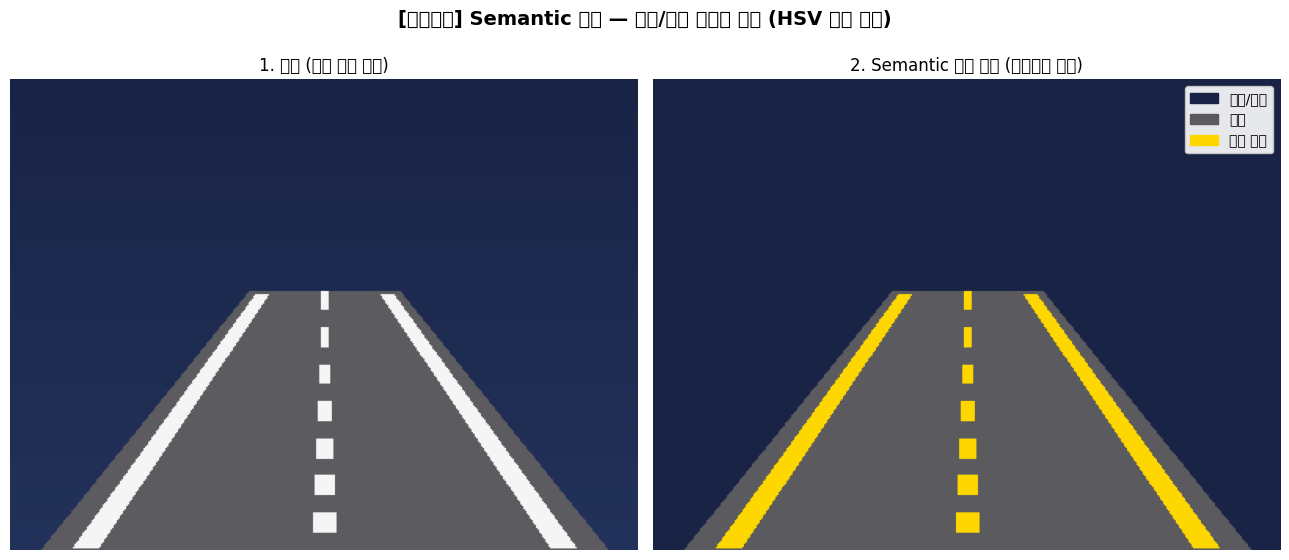

저장 완료: driving_semantic_result.png
  - 하늘/배경(클래스 0): 82,215픽셀
  - 도로(클래스 1): 32,740픽셀
  - 차선 도색(클래스 2): 5,045픽셀


In [6]:
visualizer = SemanticSegmentationVisualizer(
    title="[자율주행] Semantic 분할 — 도로/차선 클래스 분류 (HSV 색상 규칙)"
)
visualizer.save_result(result, "driving_semantic_result.png")

## 셀 6: (참고) 시맨틱 분할의 한계 확인 — 차선이 3줄(좌/우/중앙 점선)

In [7]:
# 이지만 모두 같은 라벨(클래스 2)로 칠해져 "몇 개 차선인지"는 알 수 없다.
lane_binary = result.binary_mask_of(class_id=2)
n_components, _ = cv2.connectedComponents(lane_binary.astype(np.uint8))
print(f"\n참고: 시맨틱 마스크만으로는 '차선 도색'이라는 클래스 1개만 보이지만,")
print(f"실제로는 서로 떨어진 도형 조각이 {n_components - 1}개 있습니다 "
      f"(점선은 조각이 여러 개로 끊겨 있음 — 인스턴스 분할 실습에서 "
      f"같은 차선끼리 올바르게 묶어 구분합니다).")


참고: 시맨틱 마스크만으로는 '차선 도색'이라는 클래스 1개만 보이지만,
실제로는 서로 떨어진 도형 조각이 9개 있습니다 (점선은 조각이 여러 개로 끊겨 있음 — 인스턴스 분할 실습에서 같은 차선끼리 올바르게 묶어 구분합니다).
